In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dataset = pd.read_csv("/content/iris - iris.csv")
X = dataset.iloc[:, [0, 3]].values
y = dataset.iloc[:, -1].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print("Predicted Test Results:")
print(y_pred)
print("\nActual Test Results:")
print(y_test)

from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy * 100, "%")

cm = confusion_matrix(y_test, y_pred)
print("\nModel Confusion Matrix:")
print(cm)

Predicted Test Results:
['Virginica' 'Versicolor' 'Setosa' 'Virginica' 'Setosa' 'Virginica'
 'Setosa' 'Versicolor' 'Versicolor' 'Versicolor' 'Versicolor' 'Versicolor'
 'Versicolor' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Virginica'
 'Setosa' 'Setosa' 'Versicolor' 'Versicolor' 'Setosa']

Actual Test Results:
['Virginica' 'Versicolor' 'Setosa' 'Virginica' 'Setosa' 'Virginica'
 'Setosa' 'Versicolor' 'Versicolor' 'Versicolor' 'Virginica' 'Versicolor'
 'Versicolor' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Virginica'
 'Setosa' 'Setosa' 'Versicolor' 'Versicolor' 'Setosa']

Model Accuracy: 96.66666666666667 %

Model Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Naive Bayes Model:
GaussianNB()

Predicted Results:
[0 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0
 0 1 1 1 1 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1 1 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 

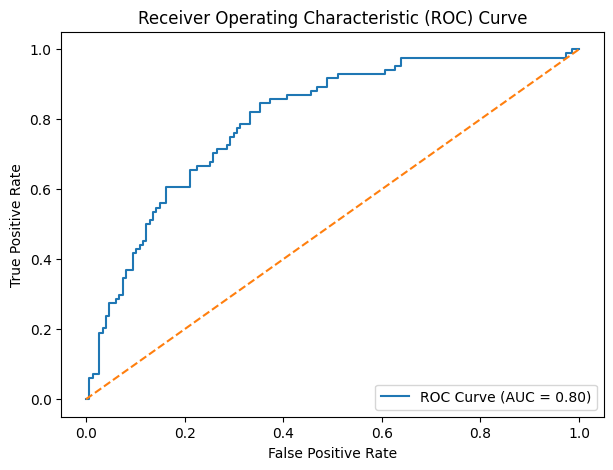

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

dataset = pd.read_csv("diabetes.csv")
print("First 5 rows of the dataset:")
print(dataset.head())
print("\n" + "=" * 50)
X = dataset.drop("Outcome", axis=1)
y = dataset["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=7
)

model = GaussianNB()
model.fit(X_train, y_train)
print("Naive Bayes Model:")
print(model)

print("\n" + "=" * 50)

y_pred = model.predict(X_test)
print("Predicted Results:")
print(y_pred)
print("\nActual Results:")
print(y_test.values)
print("\n" + "=" * 50)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy * 100, "%")
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\n" + "=" * 50)
y_predictProb = model.predict_proba(X_test)
print("Prediction Probabilities:")
print(y_predictProb)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_predictProb[:, 1]
)

roc_auc = auc(fpr, tpr)
print("\nAUC Score:", roc_auc)
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label="ROC Curve (AUC = %0.2f)" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()